# Feast Offline Store Visualization: Pandas and DuckDB

Feast stores feature metadata in the registry and delegates feature values to backing stores. In this project, the offline store is local Parquet and the online store is Redis. This notebook focuses on the offline Parquet data because it is the easiest place to inspect full feature history.

Install notebook dependencies from the repo root if needed:

```bash
pip install -r notebooks/requirements.txt
```

It shows the same data two ways:

- Pandas: dataframe-first exploration and plotting.
- DuckDB: SQL-first exploration directly over Parquet files.

In [28]:
from pathlib import Path
import os

# Keep Matplotlib cache inside the repo/session-writable temp area when needed.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

repo_root = Path.cwd()
if not (repo_root / "data" / "offline_store").exists():
    # This lets the notebook work when launched from notebooks/.
    repo_root = repo_root.parent

team_stats_path = repo_root / "data" / "offline_store" / "team_stats" / "team_stats.parquet"
matches_path = repo_root / "data" / "offline_store" / "matches" / "matches.parquet"

for path in [team_stats_path, matches_path]:
    if not path.exists():
        raise FileNotFoundError(path)

team_stats_path, matches_path

(PosixPath('/Users/rafaeltanizawa/workspace/streaming-ml-feature-store/data/offline_store/team_stats/team_stats.parquet'),
 PosixPath('/Users/rafaeltanizawa/workspace/streaming-ml-feature-store/data/offline_store/matches/matches.parquet'))

## Pandas View

Pandas loads the Parquet files into in-memory dataframes. This is usually the fastest path for quick inspection, notebook charts, and ad hoc transformations.

In [29]:
team_stats = pd.read_parquet(team_stats_path).sort_values(["event_timestamp", "team_name"])
matches = pd.read_parquet(matches_path).sort_values("event_timestamp")

print("team_stats", team_stats.shape)
display(team_stats.head())

print("matches", matches.shape)
display(matches.head())

team_stats (10772, 8)


,team_name,matches_played,wins,draws,losses,goals_for,goals_against,event_timestamp
3,flamengo_rj,1,0,1,0,1,1,2012-05-19 00:00:00+00:00
0,palmeiras,1,0,1,0,1,1,2012-05-19 00:00:00+00:00
1,portuguesa,1,0,1,0,1,1,2012-05-19 00:00:00+00:00
2,sport_recife,1,0,1,0,1,1,2012-05-19 00:00:00+00:00
13,atletico-mg,1,1,0,0,1,0,2012-05-20 00:00:00+00:00


matches (5386, 13)


,event_id,event_timestamp,home_team,away_team,home_goals,away_goals,result,odds_pinnacle_home,odds_pinnacle_draw,odds_pinnacle_away,odds_avg_home,odds_avg_draw,odds_avg_away
0,d05be2f6-2c6b-47ac-a2fa-ce4e9f635530,2012-05-19 00:00:00+00:00,palmeiras,portuguesa,1.0,1.0,D,1.75,3.86,5.25,1.69,3.50,4.90
1,9845b362-4426-4f32-8b84-acace777793b,2012-05-19 00:00:00+00:00,sport_recife,flamengo_rj,1.0,1.0,D,2.83,3.39,2.68,2.59,3.23,2.58
2,f38fc3f2-293b-4e0b-887d-7a9ece220cd9,2012-05-20 00:00:00+00:00,figueirense,nautico,2.0,1.0,H,1.60,4.04,6.72,1.59,3.67,5.64
3,4079aff5-0494-479d-b43a-feccbc255c42,2012-05-20 00:00:00+00:00,botafogo_rj,sao_paulo,4.0,2.0,H,2.49,3.35,3.15,2.35,3.26,2.84
4,2ef2a07f-72ad-48ea-81ff-09655f3f5f41,2012-05-20 00:00:00+00:00,corinthians,fluminense,0.0,1.0,A,1.96,3.53,4.41,1.89,3.33,3.89


In [30]:
display(team_stats.dtypes.to_frame("dtype"))
display(matches.dtypes.to_frame("dtype"))

,dtype
team_name,object
matches_played,int32
wins,int32
draws,int32
losses,int32
goals_for,int32
goals_against,int32
event_timestamp,"datetime64[ms, UTC]"


,dtype
event_id,object
event_timestamp,"datetime64[ms, UTC]"
home_team,object
away_team,object
home_goals,float64
away_goals,float64
result,object
odds_pinnacle_home,float64
odds_pinnacle_draw,float64
odds_pinnacle_away,float64


In [31]:
latest_team_stats = (
    team_stats.sort_values("event_timestamp")
    .groupby("team_name", as_index=False)
    .tail(1)
    .sort_values(["wins", "goals_for", "goals_against"], ascending=[False, False, True])
    .reset_index(drop=True)
)

display(latest_team_stats.head(20))

,team_name,matches_played,wins,draws,losses,goals_for,goals_against,event_timestamp
0,flamengo_rj,538,263,132,143,823,569,2026-03-19 00:00:00+00:00
1,palmeiras,501,250,114,137,762,513,2026-03-18 00:00:00+00:00
2,atletico-mg,539,239,145,154,769,607,2026-03-18 00:00:00+00:00
3,sao_paulo,539,224,151,164,678,567,2026-03-18 00:00:00+00:00
4,gremio,501,219,129,153,657,527,2026-03-19 00:00:00+00:00
5,fluminense,539,218,132,189,672,616,2026-03-19 00:00:00+00:00
6,corinthians,539,217,168,154,650,527,2026-03-20 00:00:00+00:00
7,internacional,501,205,143,153,628,535,2026-03-19 00:00:00+00:00
8,santos,501,195,141,165,634,557,2026-03-19 00:00:00+00:00
9,athletico-pr,462,184,112,166,565,508,2026-03-18 00:00:00+00:00


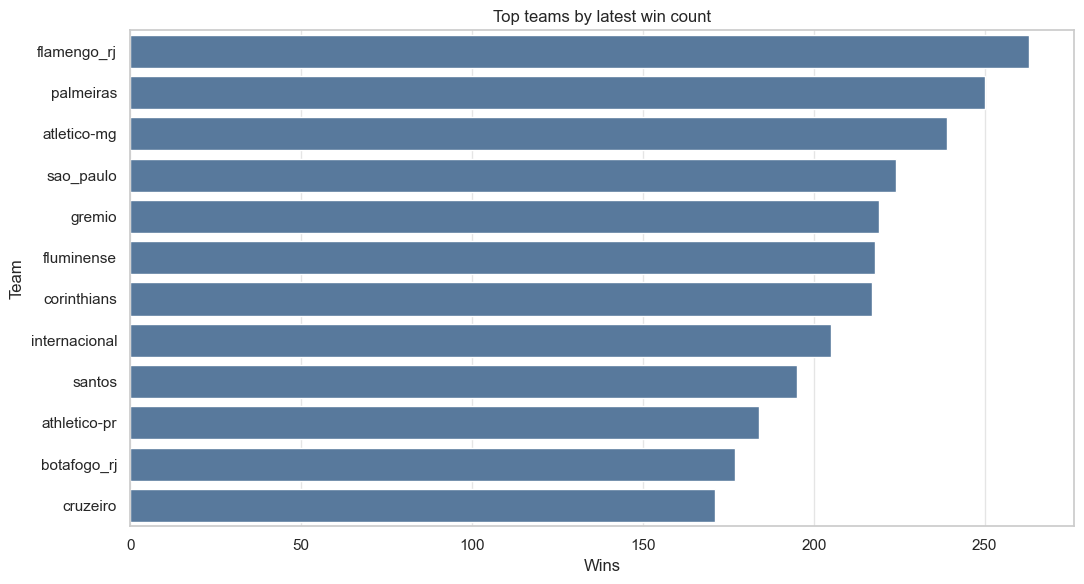

In [32]:
top_teams = latest_team_stats.head(12).copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_teams, y="team_name", x="wins", ax=ax, color="#4C78A8")
ax.set_title("Top teams by latest win count")
ax.set_xlabel("Wins")
ax.set_ylabel("Team")
plt.tight_layout()

,result,matches
0,H,2612
1,D,1447
2,A,1326


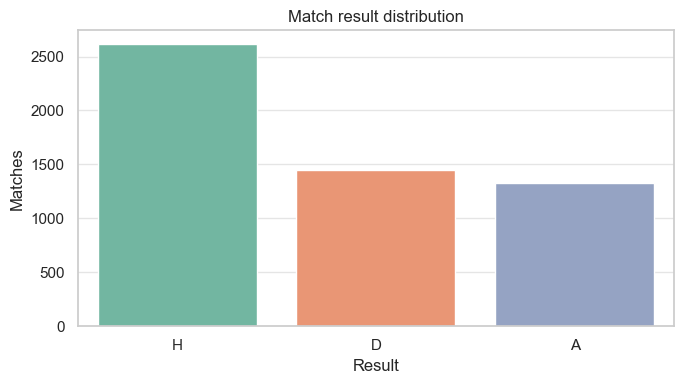

In [33]:
result_counts = matches["result"].value_counts().rename_axis("result").reset_index(name="matches")
display(result_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=result_counts, x="result", y="matches", ax=ax, palette="Set2", hue="result", legend=False)
ax.set_title("Match result distribution")
ax.set_xlabel("Result")
ax.set_ylabel("Matches")
plt.tight_layout()

,team_name,matches_played,wins,draws,losses,goals_for,goals_against,event_timestamp
10581,palmeiras,492,243,113,136,740,504,2025-11-26 00:00:00+00:00
10615,palmeiras,493,244,113,136,743,504,2025-12-04 00:00:00+00:00
10627,palmeiras,494,245,113,136,746,505,2025-12-07 00:00:00+00:00
10641,palmeiras,495,245,114,136,748,507,2026-01-28 00:00:00+00:00
10670,palmeiras,496,246,114,136,753,508,2026-02-05 00:00:00+00:00
10697,palmeiras,497,247,114,136,756,509,2026-02-13 00:00:00+00:00
10710,palmeiras,498,248,114,136,758,510,2026-02-26 00:00:00+00:00
10727,palmeiras,499,248,114,137,759,512,2026-03-12 00:00:00+00:00
10744,palmeiras,500,249,114,137,760,512,2026-03-15 00:00:00+00:00
10754,palmeiras,501,250,114,137,762,513,2026-03-18 00:00:00+00:00


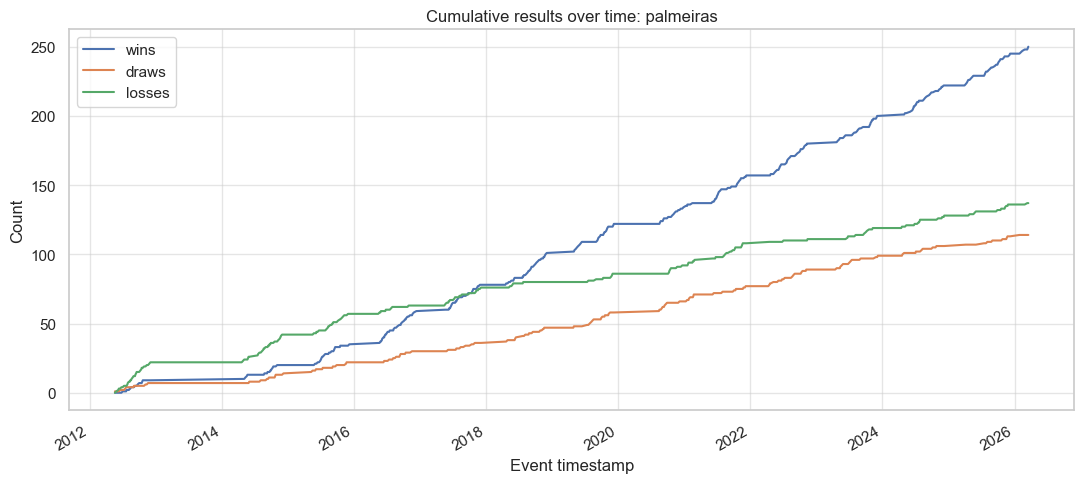

In [34]:
selected_team = "palmeiras"

team_history = team_stats.loc[team_stats["team_name"] == selected_team].sort_values("event_timestamp")
display(team_history.tail(10))

fig, ax = plt.subplots(figsize=(11, 5))
team_history.plot(x="event_timestamp", y=["wins", "draws", "losses"], ax=ax)
ax.set_title(f"Cumulative results over time: {selected_team}")
ax.set_xlabel("Event timestamp")
ax.set_ylabel("Count")
plt.tight_layout()

## DuckDB View

DuckDB lets you query the same Parquet files with SQL. It does not require loading the files into a database first.

In [35]:
try:
    import duckdb
except ModuleNotFoundError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "duckdb"])
    import duckdb

duckdb.__version__

'1.5.2'

In [36]:
con = duckdb.connect()

team_stats_sql_path = team_stats_path.as_posix()
matches_sql_path = matches_path.as_posix()

con.execute(f"CREATE OR REPLACE VIEW team_stats AS SELECT * FROM read_parquet('{team_stats_sql_path}')")
con.execute(f"CREATE OR REPLACE VIEW matches AS SELECT * FROM read_parquet('{matches_sql_path}')")

display(con.sql("DESCRIBE team_stats").df())
display(con.sql("DESCRIBE matches").df())

,column_name,column_type,null,key,default,extra
0,team_name,VARCHAR,YES,None,None,None
1,matches_played,INTEGER,YES,None,None,None
2,wins,INTEGER,YES,None,None,None
3,draws,INTEGER,YES,None,None,None
4,losses,INTEGER,YES,None,None,None
5,goals_for,INTEGER,YES,None,None,None
6,goals_against,INTEGER,YES,None,None,None
7,event_timestamp,TIMESTAMP WITH TIME ZONE,YES,None,None,None


,column_name,column_type,null,key,default,extra
0,event_id,VARCHAR,YES,None,None,None
1,event_timestamp,TIMESTAMP WITH TIME ZONE,YES,None,None,None
2,home_team,VARCHAR,YES,None,None,None
3,away_team,VARCHAR,YES,None,None,None
4,home_goals,INTEGER,YES,None,None,None
5,away_goals,INTEGER,YES,None,None,None
6,result,VARCHAR,YES,None,None,None
7,odds_pinnacle_home,DOUBLE,YES,None,None,None
8,odds_pinnacle_draw,DOUBLE,YES,None,None,None
9,odds_pinnacle_away,DOUBLE,YES,None,None,None


In [37]:
display(con.sql("""
    SELECT *
    FROM team_stats
    ORDER BY event_timestamp, team_name
    LIMIT 10
""").df())

display(con.sql("""
    SELECT *
    FROM matches
    ORDER BY event_timestamp
    LIMIT 10
""").df())

,team_name,matches_played,wins,draws,losses,goals_for,goals_against,event_timestamp
0,flamengo_rj,1,0,1,0,1,1,2012-05-18 17:00:00-07:00
1,palmeiras,1,0,1,0,1,1,2012-05-18 17:00:00-07:00
2,portuguesa,1,0,1,0,1,1,2012-05-18 17:00:00-07:00
3,sport_recife,1,0,1,0,1,1,2012-05-18 17:00:00-07:00
4,atletico-mg,1,1,0,0,1,0,2012-05-19 17:00:00-07:00
5,atletico_go,1,0,1,0,0,0,2012-05-19 17:00:00-07:00
6,bahia,1,0,1,0,0,0,2012-05-19 17:00:00-07:00
7,botafogo_rj,1,1,0,0,4,2,2012-05-19 17:00:00-07:00
8,corinthians,1,0,0,1,0,1,2012-05-19 17:00:00-07:00
9,coritiba,1,0,0,1,0,2,2012-05-19 17:00:00-07:00


,event_id,event_timestamp,home_team,away_team,home_goals,away_goals,result,odds_pinnacle_home,odds_pinnacle_draw,odds_pinnacle_away,odds_avg_home,odds_avg_draw,odds_avg_away
0,d05be2f6-2c6b-47ac-a2fa-ce4e9f635530,2012-05-18 17:00:00-07:00,palmeiras,portuguesa,1,1,D,1.75,3.86,5.25,1.69,3.50,4.90
1,9845b362-4426-4f32-8b84-acace777793b,2012-05-18 17:00:00-07:00,sport_recife,flamengo_rj,1,1,D,2.83,3.39,2.68,2.59,3.23,2.58
2,f38fc3f2-293b-4e0b-887d-7a9ece220cd9,2012-05-19 17:00:00-07:00,figueirense,nautico,2,1,H,1.60,4.04,6.72,1.59,3.67,5.64
3,4079aff5-0494-479d-b43a-feccbc255c42,2012-05-19 17:00:00-07:00,botafogo_rj,sao_paulo,4,2,H,2.49,3.35,3.15,2.35,3.26,2.84
4,2ef2a07f-72ad-48ea-81ff-09655f3f5f41,2012-05-19 17:00:00-07:00,corinthians,fluminense,0,1,A,1.96,3.53,4.41,1.89,3.33,3.89
5,25e62a43-d639-4b81-95e7-b343b58c6d8a,2012-05-19 17:00:00-07:00,internacional,coritiba,2,0,H,1.76,3.63,5.66,1.66,3.55,5.10
6,3858db6d-2f99-42b4-a33e-9bfa37bca15b,2012-05-19 17:00:00-07:00,ponte_preta,atletico-mg,0,1,A,3.12,3.45,2.44,2.74,3.23,2.45
7,24396ade-228b-46b5-8b00-30b1a7861c6d,2012-05-19 17:00:00-07:00,bahia,santos,0,0,D,2.33,3.44,3.32,2.30,3.22,2.97
8,8b9fdab9-cee5-4cf2-b6a2-cdf8c49b0dd8,2012-05-19 17:00:00-07:00,cruzeiro,atletico_go,0,0,D,1.83,3.74,4.82,1.78,3.47,4.30
9,19307bd4-5060-4f6d-b9db-700ea2c18f6a,2012-05-19 17:00:00-07:00,vasco,gremio,2,1,H,2.25,3.40,3.53,2.08,3.25,3.41


In [38]:
latest_team_stats_sql = con.sql("""
    WITH ranked AS (
        SELECT
            *,
            row_number() OVER (
                PARTITION BY team_name
                ORDER BY event_timestamp DESC
            ) AS row_num
        FROM team_stats
    )
    SELECT
        team_name,
        matches_played,
        wins,
        draws,
        losses,
        goals_for,
        goals_against,
        event_timestamp
    FROM ranked
    WHERE row_num = 1
    ORDER BY wins DESC, goals_for DESC, goals_against ASC
""").df()

display(latest_team_stats_sql.head(20))

,team_name,matches_played,wins,draws,losses,goals_for,goals_against,event_timestamp
0,flamengo_rj,538,263,132,143,823,569,2026-03-18 17:00:00-07:00
1,palmeiras,501,250,114,137,762,513,2026-03-17 17:00:00-07:00
2,atletico-mg,539,239,145,154,769,607,2026-03-17 17:00:00-07:00
3,sao_paulo,539,224,151,164,678,567,2026-03-17 17:00:00-07:00
4,gremio,501,219,129,153,657,527,2026-03-18 17:00:00-07:00
5,fluminense,539,218,132,189,672,616,2026-03-18 17:00:00-07:00
6,corinthians,539,217,168,154,650,527,2026-03-19 17:00:00-07:00
7,internacional,501,205,143,153,628,535,2026-03-18 17:00:00-07:00
8,santos,501,195,141,165,634,557,2026-03-18 17:00:00-07:00
9,athletico-pr,462,184,112,166,565,508,2026-03-17 17:00:00-07:00


,season,result,matches
0,2012,A,92
1,2012,D,105
2,2012,H,183
3,2013,A,88
4,2013,D,108
5,2013,H,184
6,2014,A,91
7,2014,D,92
8,2014,H,197
9,2015,A,89


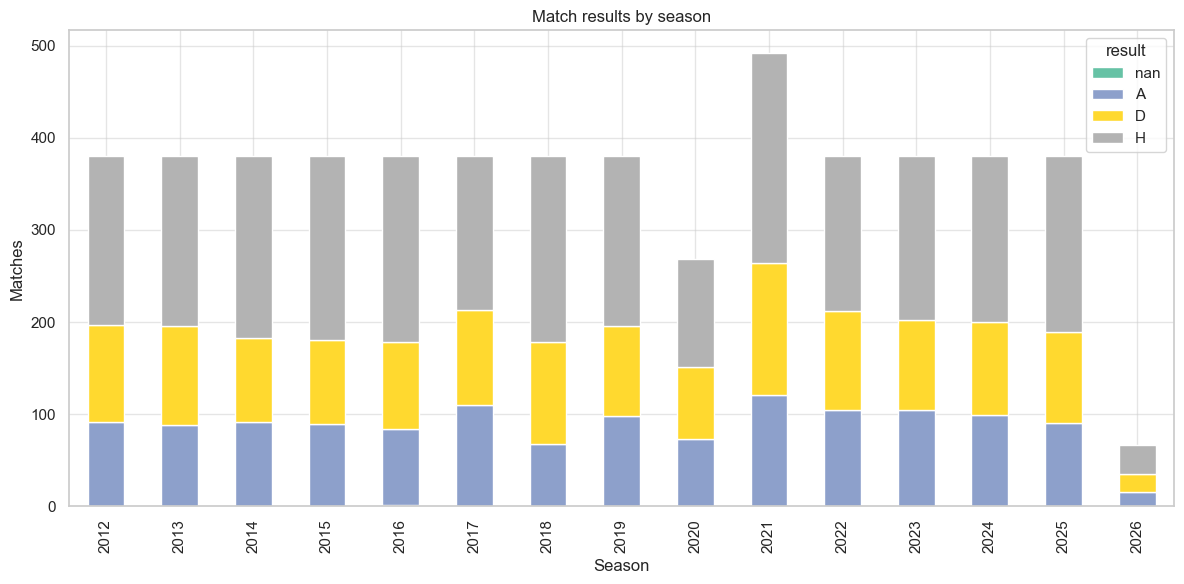

In [39]:
season_results = con.sql("""
    SELECT
        year(event_timestamp) AS season,
        result,
        count(*) AS matches
    FROM matches
    GROUP BY season, result
    ORDER BY season, result
""").df()

display(season_results.head(20))

season_pivot = season_results.pivot(index="season", columns="result", values="matches").fillna(0)
season_pivot.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")
plt.title("Match results by season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.tight_layout()

,event_timestamp,matches_played,wins,draws,losses,goals_for,goals_against
491,2025-11-25 16:00:00-08:00,492,243,113,136,740,504
492,2025-12-03 16:00:00-08:00,493,244,113,136,743,504
493,2025-12-06 16:00:00-08:00,494,245,113,136,746,505
494,2026-01-27 16:00:00-08:00,495,245,114,136,748,507
495,2026-02-04 16:00:00-08:00,496,246,114,136,753,508
496,2026-02-12 16:00:00-08:00,497,247,114,136,756,509
497,2026-02-25 16:00:00-08:00,498,248,114,136,758,510
498,2026-03-11 17:00:00-07:00,499,248,114,137,759,512
499,2026-03-14 17:00:00-07:00,500,249,114,137,760,512
500,2026-03-17 17:00:00-07:00,501,250,114,137,762,513


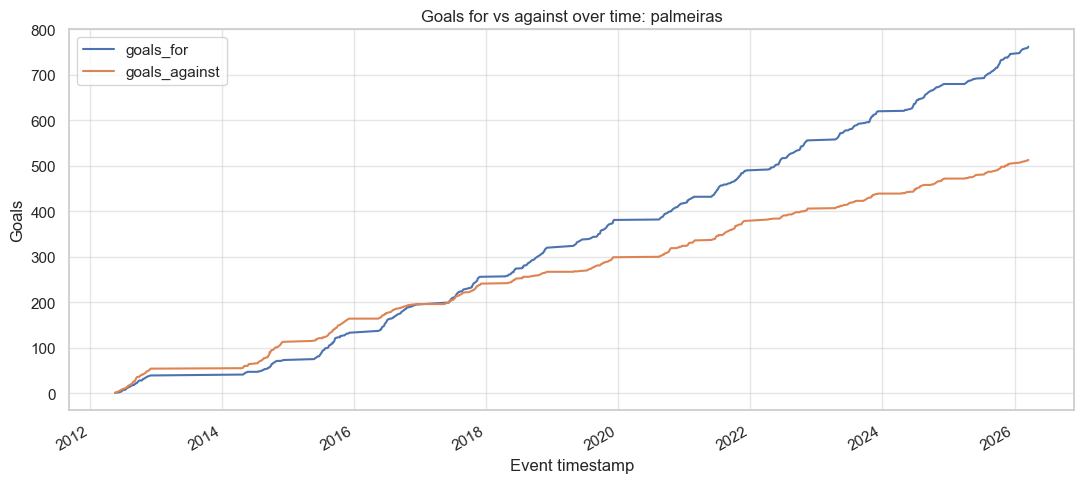

In [40]:
selected_team_sql = "palmeiras"

team_history_sql = con.sql(f"""
    SELECT
        event_timestamp,
        matches_played,
        wins,
        draws,
        losses,
        goals_for,
        goals_against
    FROM team_stats
    WHERE team_name = '{selected_team_sql}'
    ORDER BY event_timestamp
""").df()

display(team_history_sql.tail(10))

fig, ax = plt.subplots(figsize=(11, 5))
team_history_sql.plot(x="event_timestamp", y=["goals_for", "goals_against"], ax=ax)
ax.set_title(f"Goals for vs against over time: {selected_team_sql}")
ax.set_xlabel("Event timestamp")
ax.set_ylabel("Goals")
plt.tight_layout()

## Which One To Keep?

Use Pandas when you want notebook-native dataframe work, Python transformations, and quick charts.

Use DuckDB when you want SQL, joins, aggregations, filtering, or fast scans over Parquet without loading every row into memory first.

A practical pattern is to query with DuckDB, convert the result to a Pandas dataframe with `.df()`, then plot or model from that smaller result.